In [ ]:
import numpy as np
from astropy.time import Time
from scipy.interpolate import make_interp_spline

from SpaceBalls.radiation_fluxes_preprocessing import get_r_sun_day_hist, load_sh_maps, get_EEI_truth_daily_jd_arrays, expand_sh, mid_day_jd_array_from_jd_interval, get_day_jd_array
from SpaceBalls.radiation_settings import radiation_settings_from_EEI_truth_name
from SpaceBalls.sph_meshing import QuadratureGrid, Grid
from SpaceBalls.plotter import Plotter
from SpaceBalls.utils import jd_to_mmddyyyy
import config.constants as constants
AU = constants.astronomical_unit(units='km')

def get_smooth_daily_ae_hist(mid_day_jd, rad_config):

    # step 1: load few previous and next days
    n = 4 # number of days to load to built interpolator
    jd_array = mid_day_jd + np.arange(-n, n+1, 1)
    first_jd = rad_config["jd_interval"][0] + 0.5
    last_jd = rad_config["jd_interval"][1] - 0.5
    jd_array = np.delete(jd_array, jd_array<first_jd)
    jd_array = np.delete(jd_array, jd_array>last_jd)

    # step 2: load and stack a&e maps
    all_a = [None] * len(jd_array)
    all_e = [None] * len(jd_array)

    for i, jd in enumerate(jd_array):
        datestr = jd_to_mmddyyyy(jd)
        a, e = load_sh_maps(datestr, rad_config)
        all_a[i] = a
        all_e[i] = e

    stacked_a = np.stack(all_a)
    stacked_e = np.stack(all_e)

    # step 3: make splines and interpolate

    spline_a = make_interp_spline(jd_array, stacked_a, k=3)
    spline_e = make_interp_spline(jd_array, stacked_e, k=3)

    day_jd_hist = get_day_jd_array(mid_day_jd)
    day_jd_hist[day_jd_hist < first_jd] = first_jd
    day_jd_hist[day_jd_hist > last_jd] = last_jd

    a_i_hist = spline_a(day_jd_hist, extrapolate=False)
    e_i_hist = spline_e(day_jd_hist, extrapolate=False)

    return a_i_hist, e_i_hist

EEI_name = "EEI_truth_3"
rad_config = radiation_settings_from_EEI_truth_name(EEI_name)

day_idx = 5
mid_day_jd = rad_config['jd_interval'][0] + 0.5 + day_idx
all_daily_jd_arrays = get_EEI_truth_daily_jd_arrays(EEI_name)
day_jd_array = all_daily_jd_arrays[day_idx]
TSI_1AU_day = 1

a_i_hist, e_i_hist = get_smooth_daily_ae_hist(mid_day_jd, rad_config)


grid = QuadratureGrid(0, order=201, flattening=0)
full_lat, full_lon = grid.stacked_grid_latlon.T
#expand_sh(e_sh_map, full_lon, full_lat, normalization=rad_config['sh_normalization'])

for i in [700]:
    print(f"Expanding map at step_idx {i}")
    e_map = expand_sh(e_i_hist[i], full_lon, full_lat, normalization=rad_config['sh_normalization'])

    print(f"Making figure...")
    Plotter.plot_geo_data_new(e_map, grid, make_symmetric_cmap=False, 
                              title=Time(day_jd_array[i], format='jd').to_datetime())
#for jd in day_jd_array:
    


In [ ]:
from SpaceBalls.radiation_fluxes_preprocessing import compute_daily_time_series_toa, get_day_jd_array
from SpaceBalls.radiation_settings import radiation_settings_from_EEI_truth_name
from SpaceBalls.sph_meshing import QuadratureGrid
from SpaceBalls.plotter import Plotter
import numpy as np
from astropy.time import Time

TSI_1AU_day = 1
EEI_name = "EEI_truth_3"
rad_config = radiation_settings_from_EEI_truth_name(EEI_name)
day_idx = 0
mid_day_jd = rad_config['jd_interval'][0] + 0.5 + day_idx
grid = QuadratureGrid(0, order=301, flattening=0)

rad_hist, net_hist = compute_daily_time_series_toa(mid_day_jd, rad_config, TSI_1AU_day, grid)

day_jd_hist = get_day_jd_array(mid_day_jd)

for i in [0, 1439]:
    print(f"Making figure...")
    Plotter.plot_geo_data_new(rad_hist[:,i], grid, make_symmetric_cmap=False, 
                              title=Time(day_jd_hist[i], format='jd').to_datetime())
    

In [ ]:

Plotter.make_map_animation_arbitrary_frame(rad_hist, day_jd_hist, grid, 
                                           'Net', '.', 'test_animation.mp4',
                                           R_mat_hist=np.stack([np.eye(3) for _ in range(len(day_jd_hist))]),
                                           add_satellite_positions=False,
                                           add_groundtracks=False)

In [ ]:
for jd in day_jd_array:
    print(Time(jd, format='jd', scale='utc').to_datetime())

In [ ]:
# attempt to make it more efficient

import numpy as np
from astropy.time import Time
from scipy.interpolate import make_interp_spline

from SpaceBalls.radiation_fluxes_preprocessing import get_r_sun_day_hist, load_sh_maps, get_EEI_truth_daily_jd_arrays, expand_sh, mid_day_jd_array_from_jd_interval, get_day_jd_array
from SpaceBalls.radiation_settings import radiation_settings_from_EEI_truth_name
from SpaceBalls.sph_meshing import QuadratureGrid
from SpaceBalls.plotter import Plotter
from SpaceBalls.utils import jd_to_mmddyyyy
import config.constants as constants
AU = constants.astronomical_unit(units='km')

def get_expanded_smooth_daily_ae_hist(mid_day_jd, rad_config, grid: Grid):

    # step 1: load few previous and next days
    n = 4 # number of days to load to built interpolator
    jd_array = mid_day_jd + np.arange(-n, n+1, 1)
    first_jd = rad_config["jd_interval"][0] + 0.5
    last_jd = rad_config["jd_interval"][1] - 0.5
    jd_array = np.delete(jd_array, jd_array<first_jd)
    jd_array = np.delete(jd_array, jd_array>last_jd)

    # step 2: load, expand and stack a&e maps
    full_lat, full_lon = grid.stacked_grid_latlon.T
    
    all_a = [None] * len(jd_array)
    all_e = [None] * len(jd_array)

    for i, jd in enumerate(jd_array):
        datestr = jd_to_mmddyyyy(jd)
        a, e = load_sh_maps(datestr, rad_config)
        all_a[i] = expand_sh(a, full_lon, full_lat, rad_config['sh_normalization'])
        all_e[i] = expand_sh(e, full_lon, full_lat, rad_config['sh_normalization'])

    stacked_a = np.stack(all_a)
    stacked_e = np.stack(all_e)

    # step 3: make splines and interpolate

    spline_a = make_interp_spline(jd_array, stacked_a, k=3)
    spline_e = make_interp_spline(jd_array, stacked_e, k=3)

    day_jd_hist = get_day_jd_array(mid_day_jd)
    day_jd_hist[day_jd_hist < first_jd] = first_jd
    day_jd_hist[day_jd_hist > last_jd] = last_jd

    a_i_hist = spline_a(day_jd_hist, extrapolate=False)
    e_i_hist = spline_e(day_jd_hist, extrapolate=False)

    return a_i_hist, e_i_hist

EEI_name = "EEI_truth_3"
rad_config = radiation_settings_from_EEI_truth_name(EEI_name)

day_idx = 5
mid_day_jd = rad_config['jd_interval'][0] + 0.5 + day_idx
all_daily_jd_arrays = get_EEI_truth_daily_jd_arrays(rad_config['jd_interval'])
day_jd_array = all_daily_jd_arrays[day_idx]
TSI_1AU_day = 1360


grid = QuadratureGrid(0, order=301, flattening=0)
full_lat, full_lon = grid.stacked_grid_latlon.T
#expand_sh(e_sh_map, full_lon, full_lat, normalization=rad_config['sh_normalization'])

a_i_hist, e_i_hist = get_expanded_smooth_daily_ae_hist(mid_day_jd, rad_config, grid)

for i in [0, 500, 1000, 1439]:
    print(f"Expanding map at step_idx {i}")
    #e_map = expand_sh(e_i_hist[i], full_lon, full_lat, normalization=rad_config['sh_normalization'])
    a_map = a_i_hist[i]
    print(f"Making figure...")
    Plotter.plot_geo_data_new(a_map, grid, make_symmetric_cmap=False, 
                              title=Time(day_jd_array[i], format='jd').to_datetime())
#for jd in day_jd_array:
    


Getting smooth daily ae hist...
Getting smooth daily ae hist...
Making figure...
Making figure...
Making figure...
Making figure...
Making figure...
Making figure...
Making figure...
Making figure...


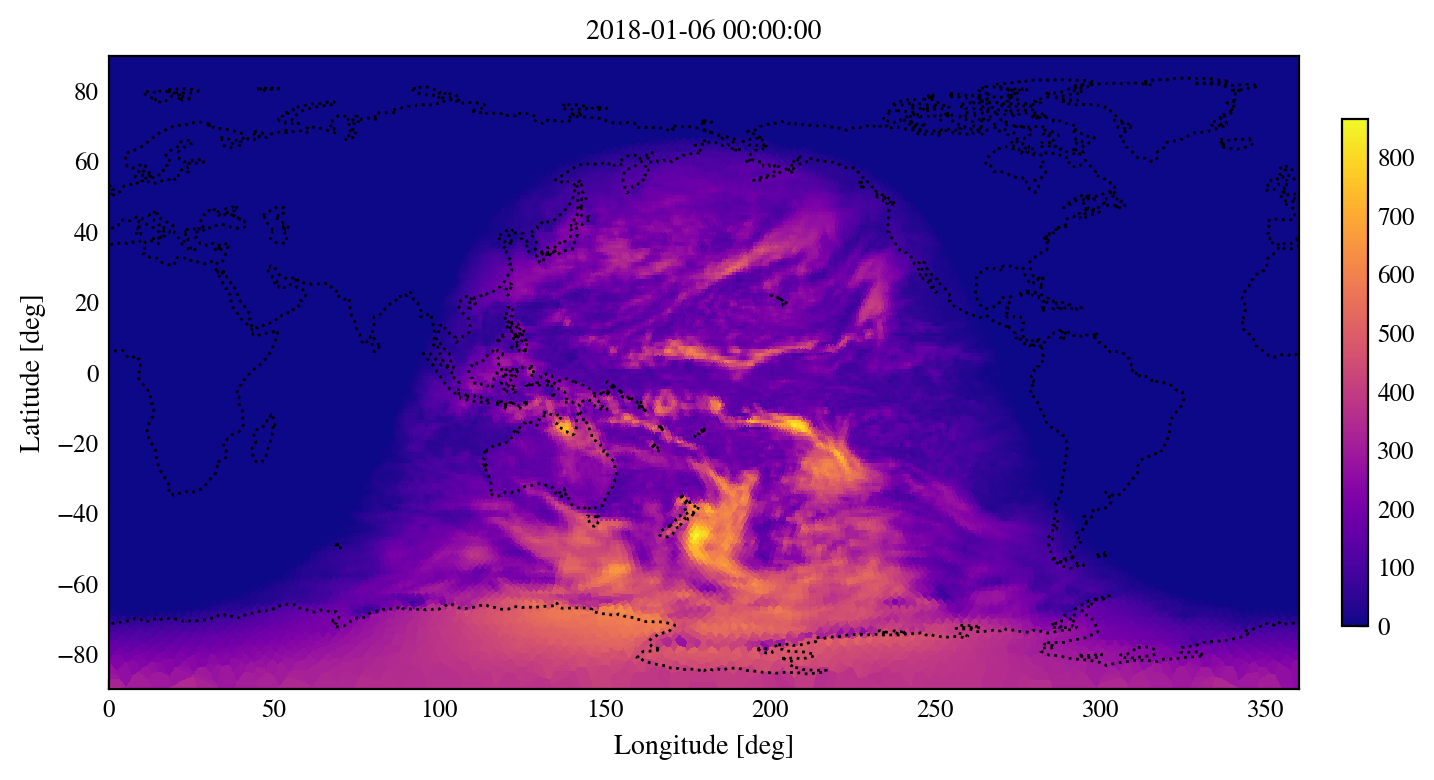

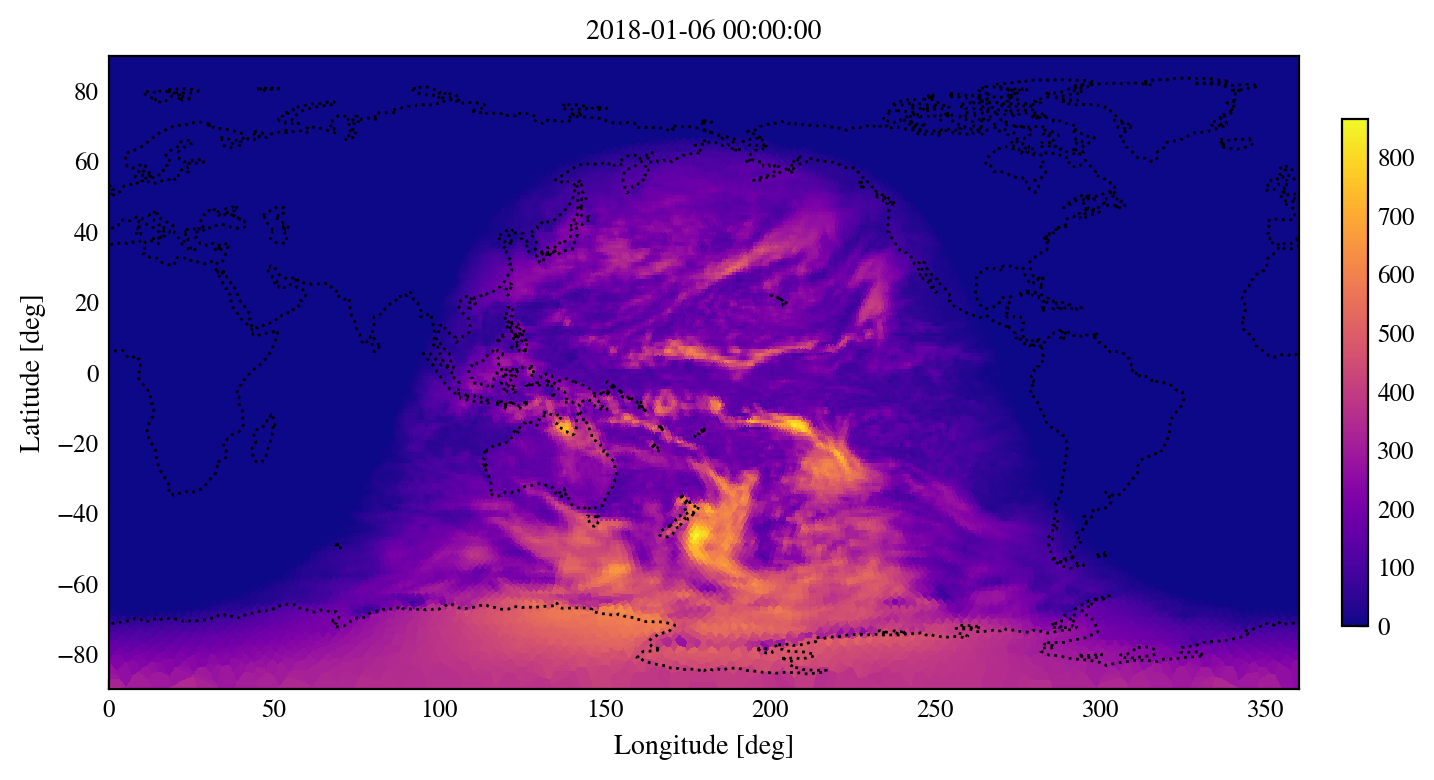

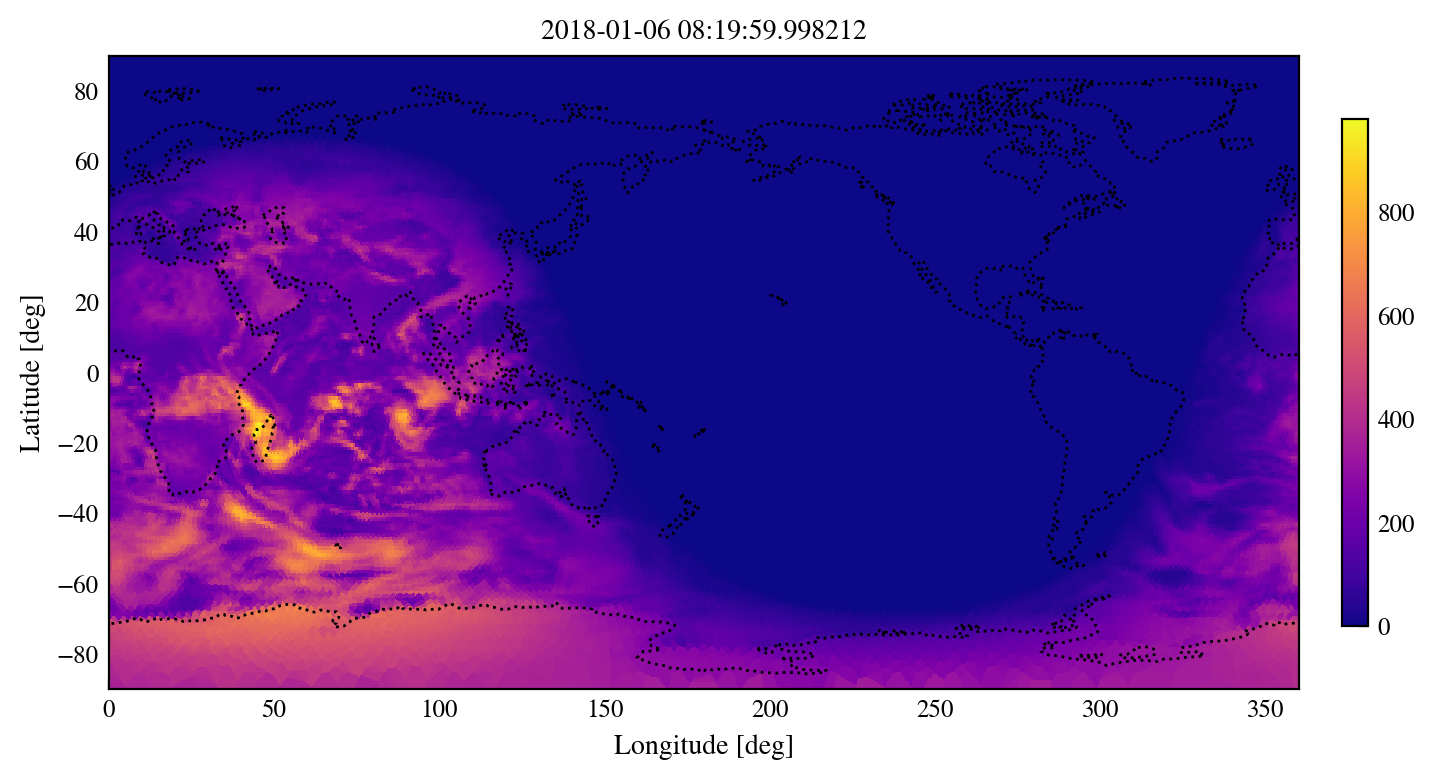

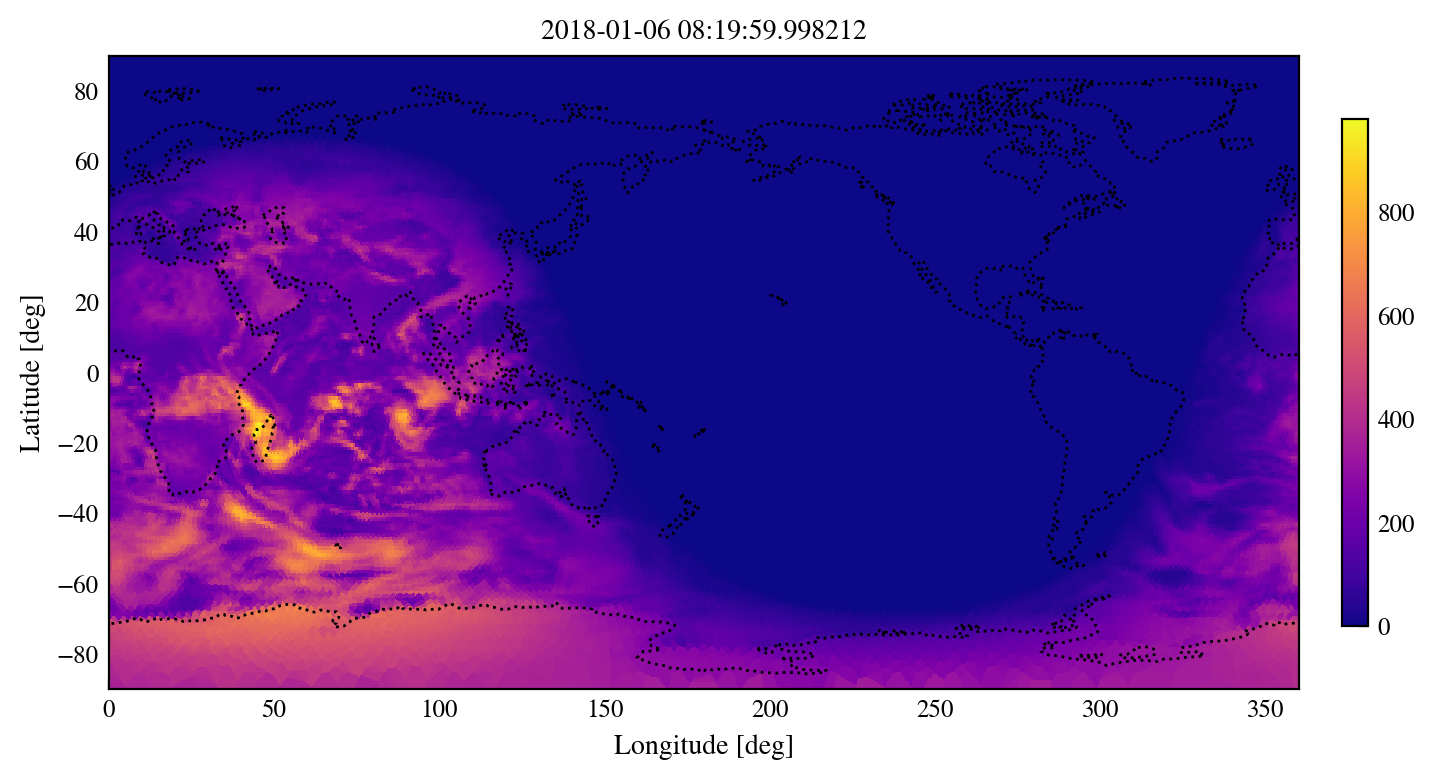

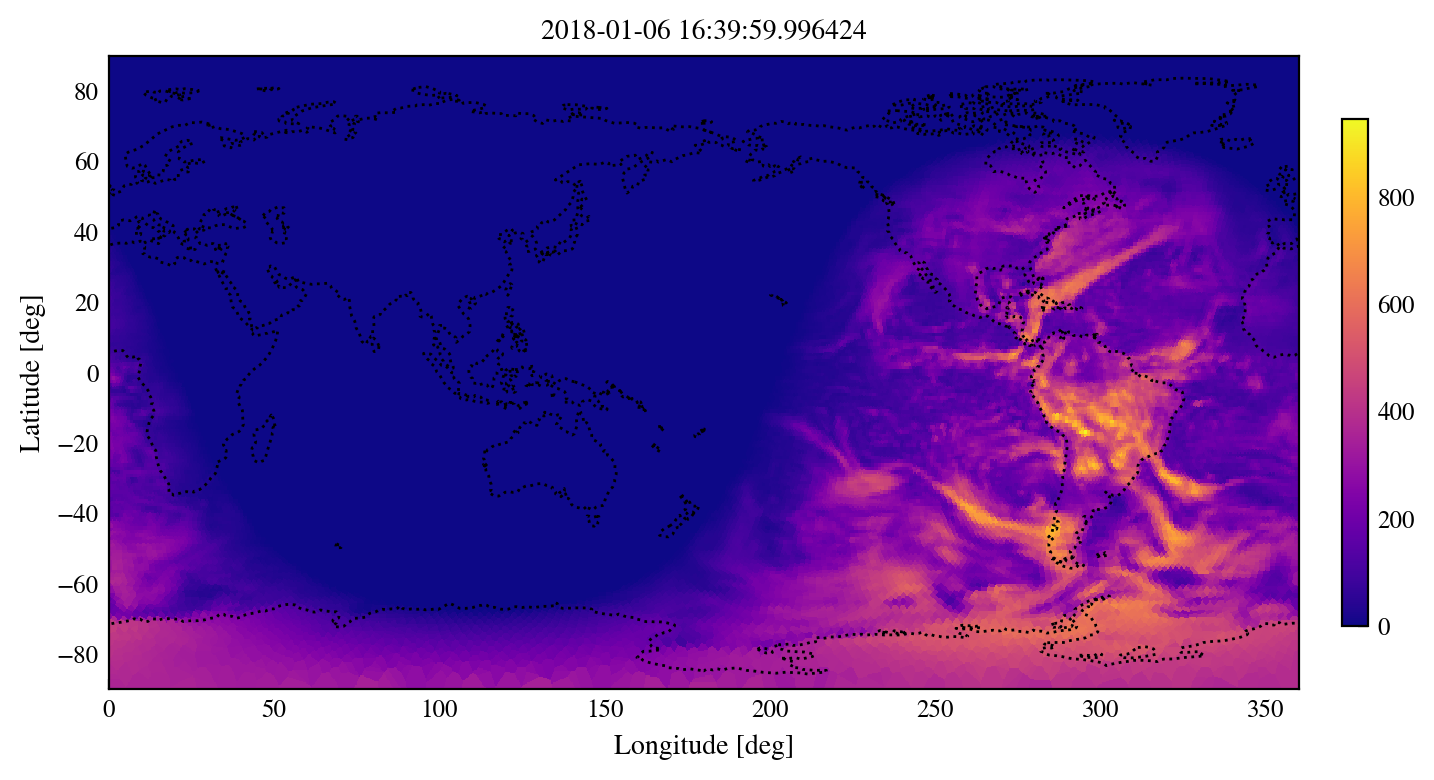

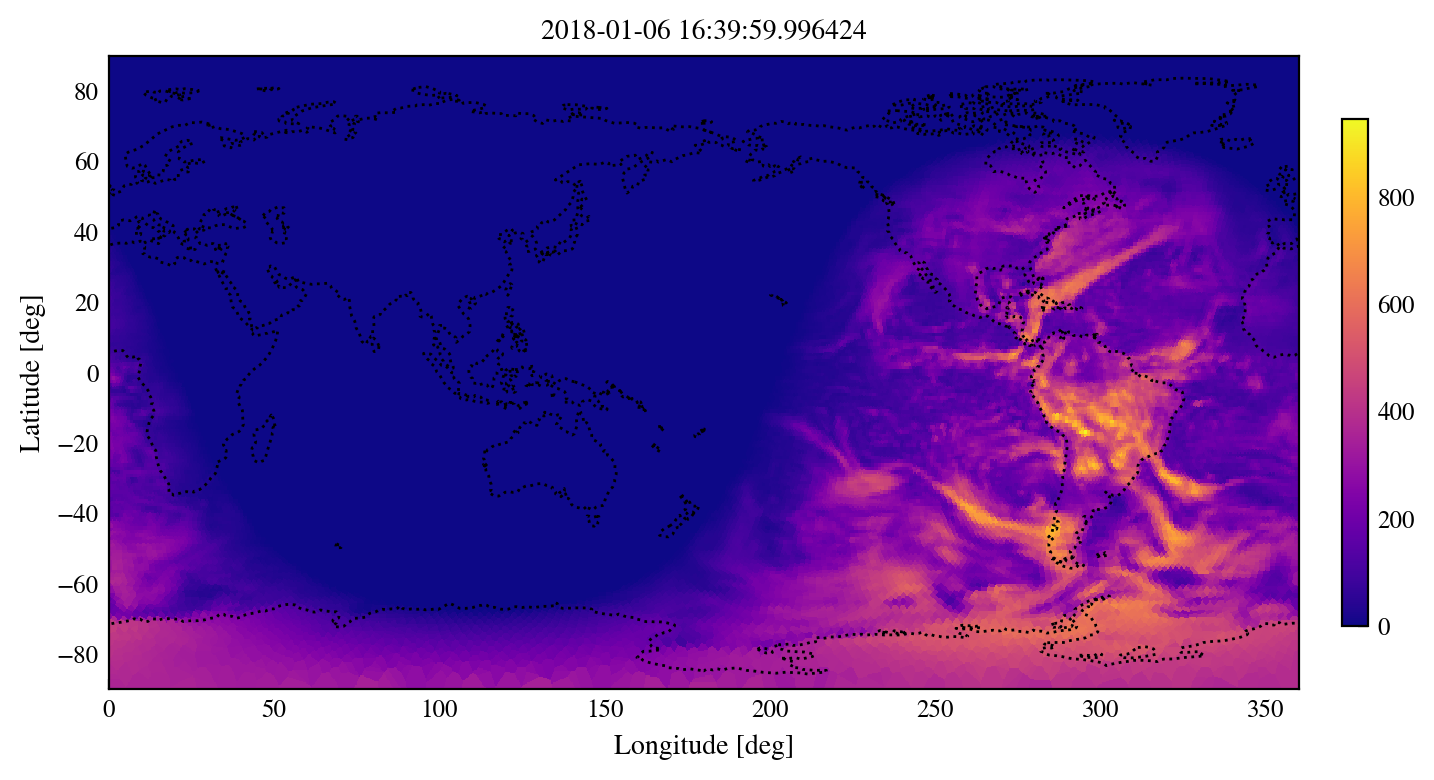

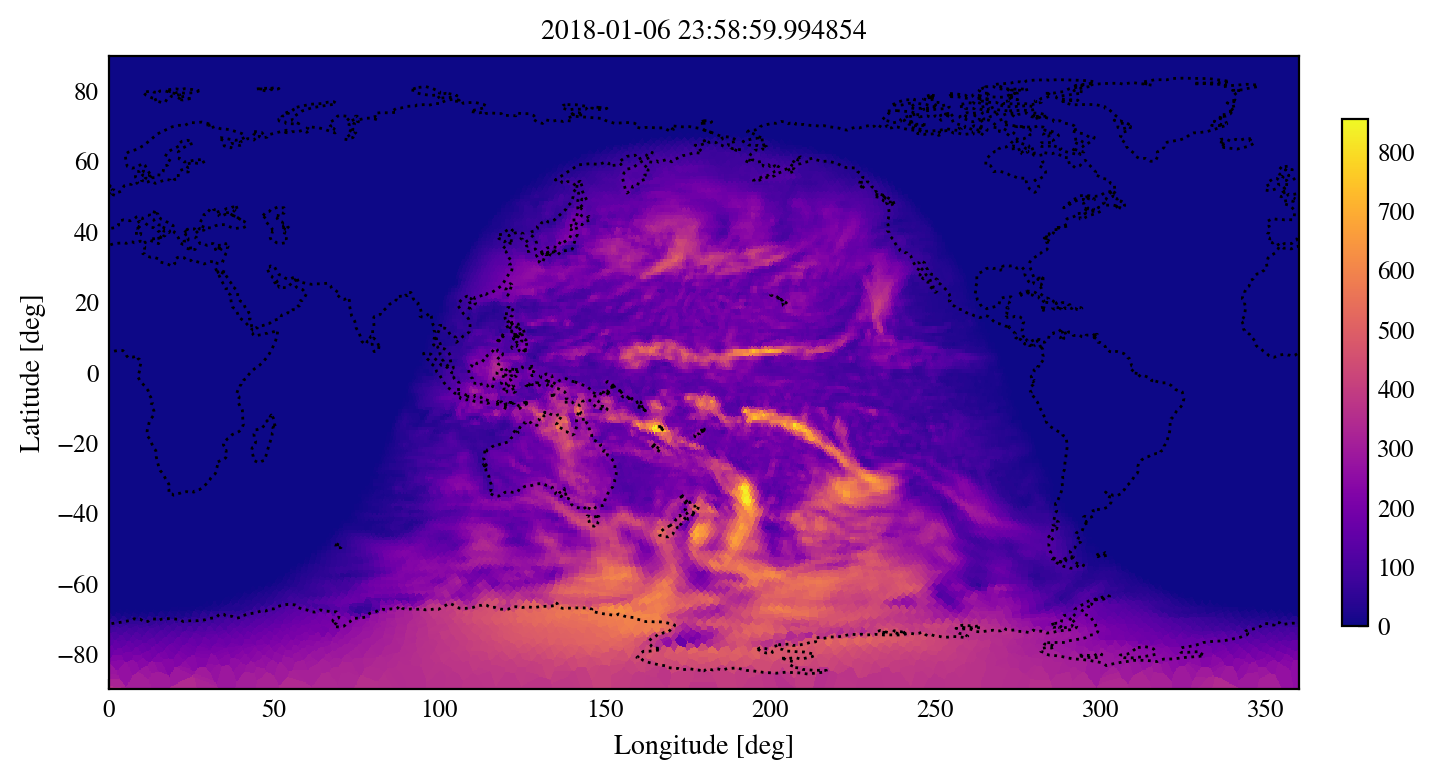

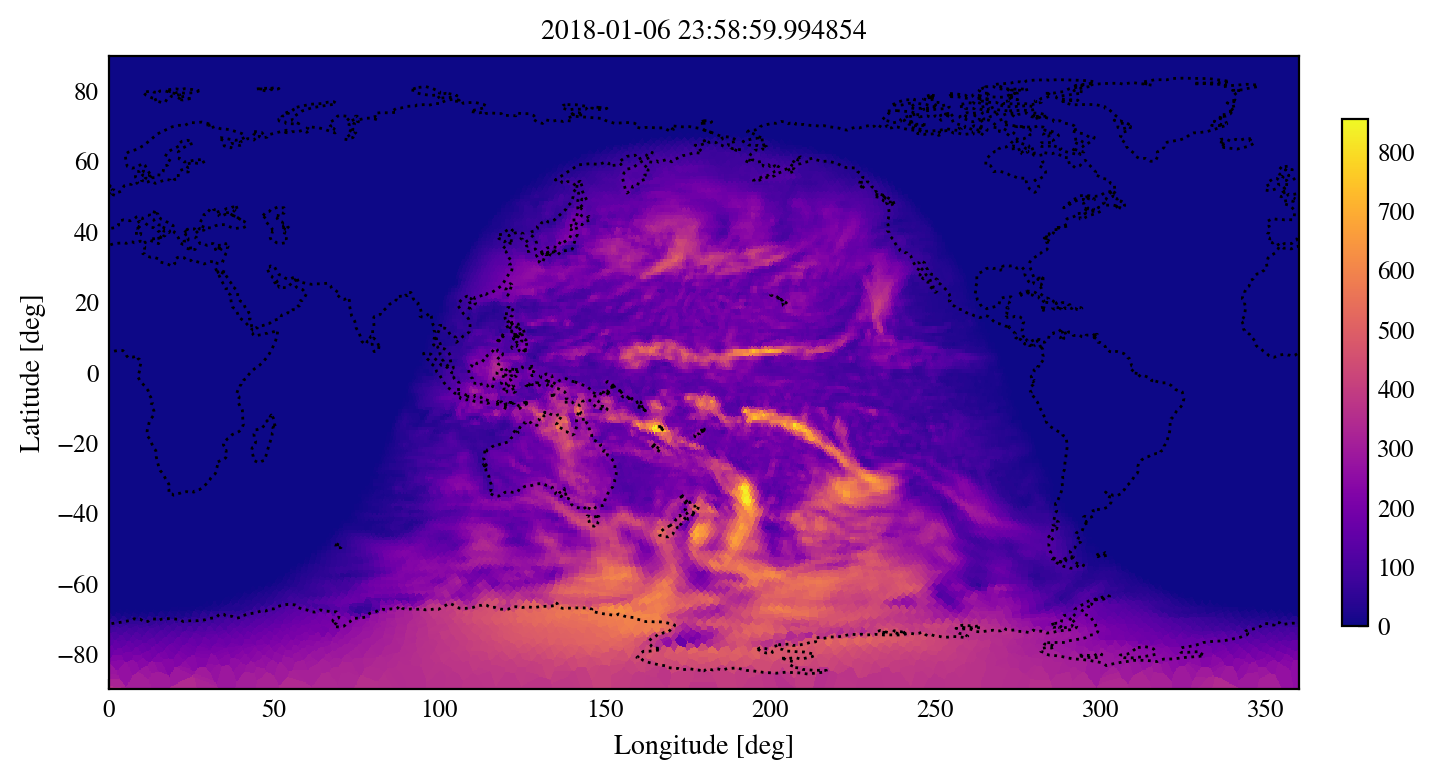

In [1]:
# using the final implementation

import numpy as np
from astropy.time import Time
from scipy.interpolate import make_interp_spline

from SpaceBalls.radiation_fluxes_preprocessing import compute_flux_hist_toa, get_smooth_daily_ae_hist, load_sh_maps, get_EEI_truth_daily_jd_arrays, expand_sh, mid_day_jd_array_from_jd_interval, get_day_jd_array
from SpaceBalls.radiation_settings import radiation_settings_from_EEI_truth_name
from SpaceBalls.sph_meshing import QuadratureGrid
from SpaceBalls.plotter import Plotter
from SpaceBalls.utils import jd_to_mmddyyyy
import config.constants as constants
AU = constants.astronomical_unit(units='km')

EEI_name = "EEI_truth_3"
rad_config = radiation_settings_from_EEI_truth_name(EEI_name)

day_idx = 5
mid_day_jd = rad_config['jd_interval'][0] + 0.5 + day_idx
all_daily_jd_arrays = get_EEI_truth_daily_jd_arrays(rad_config['jd_interval'])
day_jd_array = all_daily_jd_arrays[day_idx]
TSI_1AU_day = 1360


grid = QuadratureGrid(0, order=301, flattening=0)
grid_7 = QuadratureGrid(-7, order=301, flattening=0)
full_lat, full_lon = grid.stacked_grid_latlon.T
#expand_sh(e_sh_map, full_lon, full_lat, normalization=rad_config['sh_normalization'])

# get_smooth_daily_ae_hist only give a_hist and e_hist
LW_hist_7, SW_hist_7, _ = compute_flux_hist_toa(day_jd_array, rad_config, grid_7, compute_net=False)
LW_hist, SW_hist, _ = compute_flux_hist_toa(day_jd_array, rad_config, grid, compute_net=False)

for i in [0, 500, 1000, 1439]:
    #a_map = a_hist[:,i] - a_hist_7[:,i]
    sw_map = SW_hist[:,i]
    print(f"Making figure...")
    Plotter.plot_geo_data_new(sw_map, grid, make_symmetric_cmap=False, 
                              title=Time(day_jd_array[i], format='jd').to_datetime())
    sw_map = SW_hist_7[:,i]
    print(f"Making figure...")
    Plotter.plot_geo_data_new(sw_map, grid, make_symmetric_cmap=False, 
                              title=Time(day_jd_array[i], format='jd').to_datetime())


#for jd in day_jd_array:
    